<a href="https://colab.research.google.com/github/anikaumaselvan/academic_projects/blob/main/Course_Project_SYS_3051.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predicting Team Wins and Playoff Qualification from NBA Season Data**

Anika Umaselvan, Riley Meana, Liza Angell, Sam Leal

**SYS 3051 Fall 2025**

This project explores how player and team performance metrics can be used to predict playoff qualifications. Understanding which features most influence team performance and wins can help coaches identify strategies for game planning and roster building. The project will answer what statistical factors most contribute to the playoff qualifications of NBA teams. It will also address if AI-driven models can accurately predict team wins and their likelihood of making it to the playoffs.

**Research Questions**

-	How does individual player performance influence the likelihood of team wins?
-	Which factors from past NBA game statistics best predict team wins and playoff qualifications?

**Objectives**

Objective 1: Process player and game statistics into interpretable team performance indicators.
Objective 2: Develop and compare predictive models.
Objective 3: Assess model accuracy and analyze which statistical features most strongly contribute to team success outcomes.


**Dataset Description**

https://www.kaggle.com/datasets/nathanlauga/nba-games/data

The dataset used in this project includes statistics of players for a given game, team rankings, and final game scores from 2004 to 2020. The data was collected from the official NBA Statistics website that provides accurate historical game and player data. The data was cleaned to provide information across several years in a formatted way. There are no privacy concerns, because the data was collected from publicly provided information. An ethical use concern may include avoiding biased interpretations of player or team statistics.

**Features/Variables**

**	Key variables in the dataset are team and player names, field goals attempts, minutes played, three-point percentage, offensive and defensive rebounds, turnovers, steals, personal fouls, and field goal percentage.**


**Data Preparation**

The original dataset from Kaggle included multiple CSV's: games.csv, games_details.csv, players.csv, teams.csv, and rankings.csv. For our main research question of predicting playoff performance, much of the information in these datasets was unecessary, so we had to analyze and select specific columns to merge within one csv. THe first attempt we made was to merge all the csv's in their entirety, but found that there were then too many observations and the dataframe grew unwieldy and hard to process. For the second attempt, we created a much smaller csv using Rstudio which kept limited columns and went by overall team performance averages throughout each season to reduce the number of observations.





In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

datadir = "/content/drive/MyDrive/SYS3051/Data"

games = pd.read_csv(f"{datadir}/games.csv")
games_details = pd.read_csv(f"{datadir}/games_details.csv")
players = pd.read_csv(f"{datadir}/players.csv")
teams = pd.read_csv(f"{datadir}/teams.csv")
ranking = pd.read_csv(f"{datadir}/ranking.csv")

games["GAME_DATE_EST"] = pd.to_datetime(games["GAME_DATE_EST"], errors="coerce")
games = games.dropna(subset=["GAME_DATE_EST"])


min_split = games_details["MIN"].astype(str).str.split(":", expand=True)
games_details["min"] = pd.to_numeric(min_split[0], errors="coerce")
games_details["sec"] = pd.to_numeric(min_split[1], errors="coerce").fillna(0)
games_details["MIN"] = games_details["min"] + games_details["sec"] / 60
games_details = games_details.drop(columns=["min", "sec"])

players = players.rename(columns={"TEAM_ID": "PLAYER_TEAM_ID"})
players = players.dropna(subset=["PLAYER_ID"])

ranking["STANDINGSDATE"] = pd.to_datetime(ranking["STANDINGSDATE"], errors="coerce")
ranking = ranking.dropna(subset=["STANDINGSDATE"])


home = games.assign(
    TEAM_ID=games["TEAM_ID_home"],
    PTS_FOR=games["PTS_home"],
    PTS_AGAINST=games["PTS_away"],
    FG_PCT=games["FG_PCT_home"],
    FT_PCT=games["FT_PCT_home"],
    FG3_PCT=games["FG3_PCT_home"],
    AST=games["AST_home"],
    REB=games["REB_home"],
    WIN=games["HOME_TEAM_WINS"]
)[["SEASON", "TEAM_ID", "PTS_FOR", "PTS_AGAINST", "FG_PCT",
   "FT_PCT", "FG3_PCT", "AST", "REB", "WIN"]]

away = games.assign(
    TEAM_ID=games["TEAM_ID_away"],
    PTS_FOR=games["PTS_away"],
    PTS_AGAINST=games["PTS_home"],
    FG_PCT=games["FG_PCT_away"],
    FT_PCT=games["FT_PCT_away"],
    FG3_PCT=games["FG3_PCT_away"],
    AST=games["AST_away"],
    REB=games["REB_away"],
    WIN=1 - games["HOME_TEAM_WINS"]
)[["SEASON", "TEAM_ID", "PTS_FOR", "PTS_AGAINST", "FG_PCT",
   "FT_PCT", "FG3_PCT", "AST", "REB", "WIN"]]

games_long = pd.concat([home, away], ignore_index=True)

# -------------------------------
# Team Season Statistics
# -------------------------------

team_season_stats = (
    games_long
    .groupby(["SEASON", "TEAM_ID"], as_index=False)
    .agg(
        PTS_FOR=("PTS_FOR", "mean"),
        PTS_AGAINST=("PTS_AGAINST", "mean"),
        FG_PCT=("FG_PCT", "mean"),
        FG3_PCT=("FG3_PCT", "mean"),
        FT_PCT=("FT_PCT", "mean"),
        REB=("REB", "mean"),
        AST=("AST", "mean"),
        WIN_PCT=("WIN", "mean")
    )
)

# -------------------------------
# Ranking & Playoff Label
# -------------------------------

ranking["SEASON"] = ranking["SEASON_ID"] % 10000

ranking_final = (
    ranking
    .sort_values("STANDINGSDATE")
    .groupby(["TEAM_ID", "SEASON"], as_index=False)
    .tail(1)
)

ranking_final["CONF_RANK"] = (
    ranking_final
    .groupby(["SEASON", "CONFERENCE"])["W_PCT"]
    .rank(method="first", ascending=False)
)

ranking_final["MADE_PLAYOFFS"] = (ranking_final["CONF_RANK"] <= 8).astype(int)

ranking_final = ranking_final[
    ["TEAM_ID", "SEASON", "W_PCT", "CONFERENCE", "MADE_PLAYOFFS"]
]

# -------------------------------
# Final Dataset
# -------------------------------

final_dataset = team_season_stats.merge(
    ranking_final,
    on=["TEAM_ID", "SEASON"],
    how="left"
)

# Save to Google Drive
output_path = f"{datadir}/nba_playoff_model_data.csv"
final_dataset.to_csv(output_path, index=False)

# Preview
print("Saved to:", output_path)
final_dataset.head()


**Data Exploration**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd

file_path = 'nba_playoff_model_data.csv'
df = pd.read_csv(file_path)
display(df.head())

,SEASON,TEAM_ID,PTS_FOR,PTS_AGAINST,FG_PCT,FG3_PCT,FT_PCT,REB,AST,WIN_PCT,W_PCT,CONFERENCE,MADE_PLAYOFFS
0,2003,1610612737,92.662651,97.289157,0.432747,0.321325,0.771711,42.746988,20.072289,0.366667,0.341,East,0
1,2003,1610612738,94.689655,97.000000,0.442609,0.336115,0.756667,40.126437,20.390805,0.425532,0.439,East,1
2,2003,1610612739,92.880952,95.357143,0.435357,0.320976,0.745857,45.642857,22.071429,0.455556,0.427,East,0
3,2003,1610612740,91.088889,91.333333,0.419767,0.318556,0.752411,42.711111,20.866667,0.515464,0.500,East,1
4,2003,1610612741,89.313253,95.638554,0.416530,0.350482,0.722458,43.349398,21.722892,0.288889,0.280,East,0


In [ ]:
display(df.describe())

,SEASON,TEAM_ID,PTS_FOR,PTS_AGAINST,FG_PCT,FG3_PCT,FT_PCT,REB,AST,WIN_PCT,W_PCT,MADE_PLAYOFFS
count,599.000000,5.990000e+02,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000
mean,2012.515860,1.610613e+09,102.333880,102.567396,0.455107,0.352188,0.759979,42.779872,22.229800,0.492134,0.499808,0.534224
std,5.762815,8.649569e+00,7.069141,7.136186,0.015177,0.018517,0.029679,2.116562,2.228192,0.137905,0.149216,0.499244
min,2003.000000,1.610613e+09,85.325301,83.682243,0.410989,0.288191,0.660658,36.181818,17.277778,0.117647,0.106000,0.000000
25%,2008.000000,1.610613e+09,96.971705,97.334662,0.444701,0.339742,0.741537,41.366454,20.628592,0.396538,0.390000,0.000000
50%,2013.000000,1.610613e+09,101.375000,101.733333,0.454350,0.351626,0.760272,42.705882,21.971963,0.500000,0.512000,1.000000
75%,2017.500000,1.610613e+09,107.805904,107.686878,0.465293,0.364354,0.780762,44.069944,23.664794,0.594494,0.610000,1.000000
max,2022.000000,1.610613e+09,118.750000,119.183908,0.501861,0.405018,0.839812,50.879121,29.792453,0.839623,0.890000,1.000000


**Exploratory Visualizations**


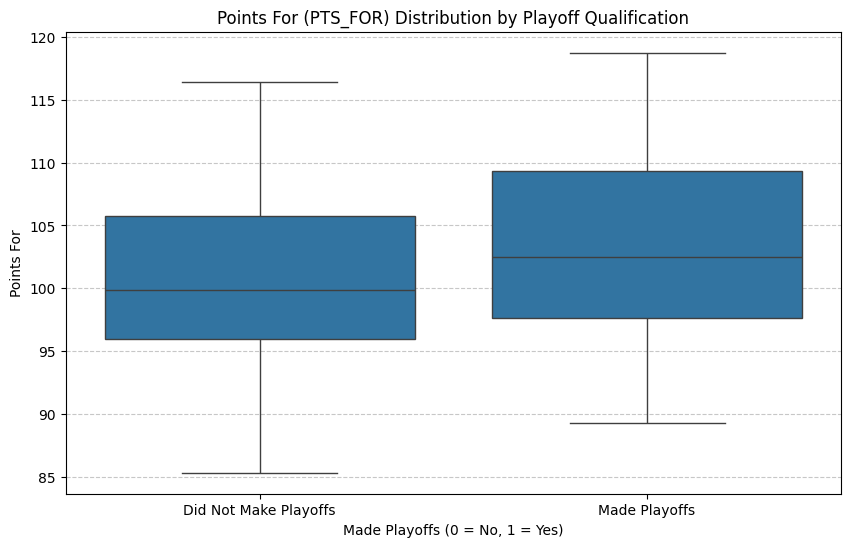


Mean Points For by Playoff Qualification:
Teams that Did Not Make Playoffs (MADE_PLAYOFFS=0): 101.12
Teams that Made Playoffs (MADE_PLAYOFFS=1): 103.40


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='MADE_PLAYOFFS', y='PTS_FOR', data=df)
plt.title('Points For (PTS_FOR) Distribution by Playoff Qualification')
plt.xlabel('Made Playoffs (0 = No, 1 = Yes)')
plt.ylabel('Points For')
plt.xticks([0, 1], ['Did Not Make Playoffs', 'Made Playoffs'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Calculate the mean PTS_FOR for each group
mean_pts_for_by_playoffs = df.groupby('MADE_PLAYOFFS')['PTS_FOR'].mean()

# 3. Print the calculated mean PTS_FOR for both groups
print("\nMean Points For by Playoff Qualification:")
print(f"Teams that Did Not Make Playoffs (MADE_PLAYOFFS=0): {mean_pts_for_by_playoffs[0]:.2f}")
print(f"Teams that Made Playoffs (MADE_PLAYOFFS=1): {mean_pts_for_by_playoffs[1]:.2f}")

In this first plot, it can be seen that the distribution of points scored by the teams which made the playoffs were much higher than the teams which did not make the playoffs. The mean amount of points for with teams that made the playoffs was more than two points higher than teams that did not make the playoffs. Points for is an important variable which is a strong predictor of a team's ability to make the playoffs.

Correlation between PTS_FOR and AST: 0.7166


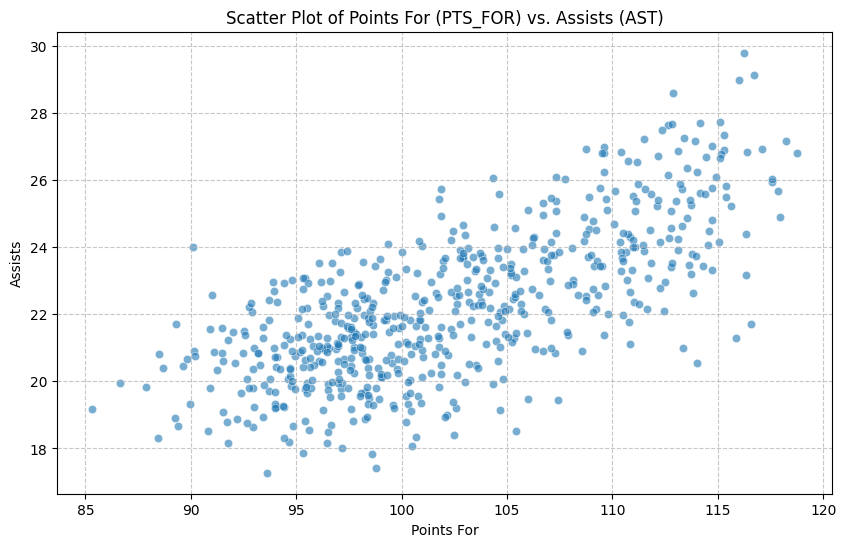

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation coefficient
correlation = df['PTS_FOR'].corr(df['AST'])
print(f"Correlation between PTS_FOR and AST: {correlation:.4f}")

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PTS_FOR', y='AST', data=df, alpha=0.6)
plt.title('Scatter Plot of Points For (PTS_FOR) vs. Assists (AST)')
plt.xlabel('Points For')
plt.ylabel('Assists')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Based on the plot above, there is a clear positive correlation between the points a team scores and the number of assists per game. This is an important realization as points for is one of the strongest predictors of making the playoffs. Discovered in a previous plot, teams which make the playoffs tend to have a higher amount of points scored per game, and if assists has a positive correlation with points for, it is also an important predictor of making the playoffs.

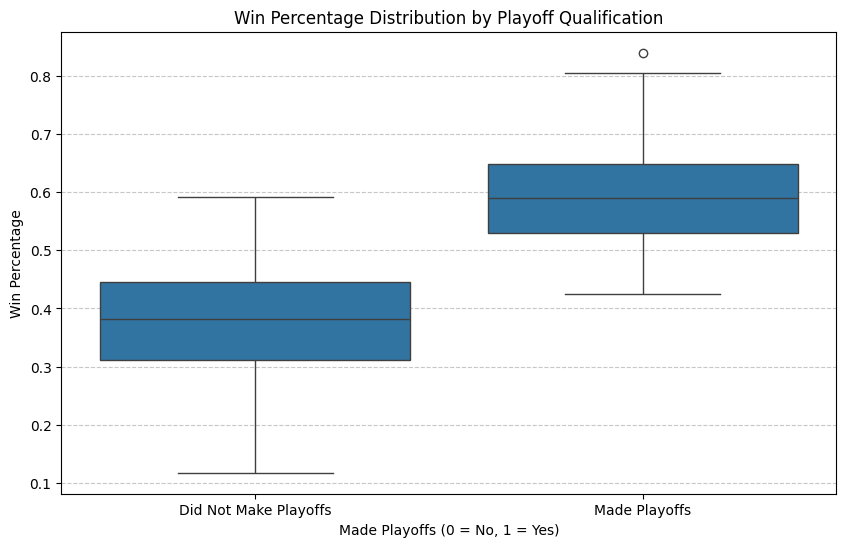


Mean Win Percentage by Playoff Qualification:
Teams that Did Not Make Playoffs (MADE_PLAYOFFS=0): 0.3764
Teams that Made Playoffs (MADE_PLAYOFFS=1): 0.5931


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='MADE_PLAYOFFS', y='WIN_PCT', data=df)
plt.title('Win Percentage Distribution by Playoff Qualification')
plt.xlabel('Made Playoffs (0 = No, 1 = Yes)')
plt.ylabel('Win Percentage')
plt.xticks([0, 1], ['Did Not Make Playoffs', 'Made Playoffs'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Calculate the mean WIN_PCT for each group
mean_win_pct_by_playoffs = df.groupby('MADE_PLAYOFFS')['WIN_PCT'].mean()

print("\nMean Win Percentage by Playoff Qualification:")
print(f"Teams that Did Not Make Playoffs (MADE_PLAYOFFS=0): {mean_win_pct_by_playoffs[0]:.4f}")
print(f"Teams that Made Playoffs (MADE_PLAYOFFS=1): {mean_win_pct_by_playoffs[1]:.4f}")

One of the strongest differences seen visually, win percentage distribution greatly differs between teams which made the playoffs and those that did not. This discovery indicates that for future model performance, win percentage is a variable that should closely be analyzed and heavily weighted when predicting a team's ability to make the playoffs, as there is little overlap in the distribution on each different playoff status.

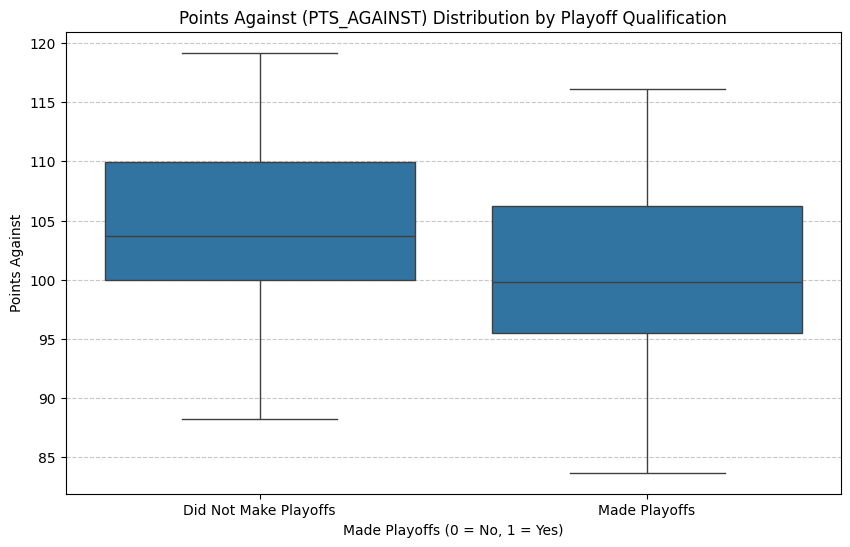


Mean Points Against by Playoff Qualification:
Teams that Did Not Make Playoffs (MADE_PLAYOFFS=0): 104.76
Teams that Made Playoffs (MADE_PLAYOFFS=1): 100.65


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='MADE_PLAYOFFS', y='PTS_AGAINST', data=df)
plt.title('Points Against (PTS_AGAINST) Distribution by Playoff Qualification')
plt.xlabel('Made Playoffs (0 = No, 1 = Yes)')
plt.ylabel('Points Against')
plt.xticks([0, 1], ['Did Not Make Playoffs', 'Made Playoffs'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Calculate the mean PTS_AGAINST for each group
mean_pts_against_by_playoffs = df.groupby('MADE_PLAYOFFS')['PTS_AGAINST'].mean()

# 3. Print the calculated mean PTS_AGAINST for both groups
print("\nMean Points Against by Playoff Qualification:")
print(f"Teams that Did Not Make Playoffs (MADE_PLAYOFFS=0): {mean_pts_against_by_playoffs[0]:.2f}")
print(f"Teams that Made Playoffs (MADE_PLAYOFFS=1): {mean_pts_against_by_playoffs[1]:.2f}")

An interesting relationship that came up is that teams which made the playoffs had a lower distribution of points scored against them per game. This is an intuitive relationship, but still interesting to see visualized as it cued our team to take this important variable into account when constructing our model.

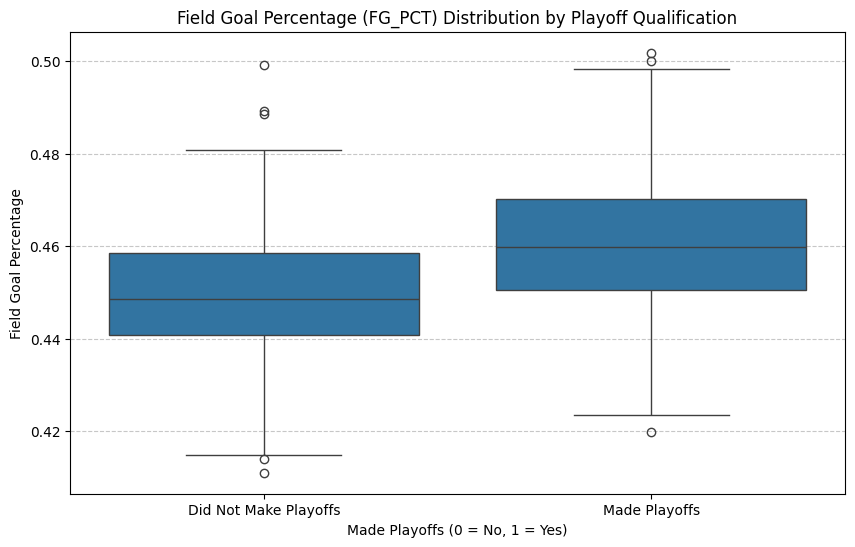


Mean Field Goal Percentage by Playoff Qualification:
Teams that Did Not Make Playoffs (MADE_PLAYOFFS=0): 0.4491
Teams that Made Playoffs (MADE_PLAYOFFS=1): 0.4603


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='MADE_PLAYOFFS', y='FG_PCT', data=df)
plt.title('Field Goal Percentage (FG_PCT) Distribution by Playoff Qualification')
plt.xlabel('Made Playoffs (0 = No, 1 = Yes)')
plt.ylabel('Field Goal Percentage')
plt.xticks([0, 1], ['Did Not Make Playoffs', 'Made Playoffs'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Calculate the mean FG_PCT for each group
mean_fg_pct_by_playoffs = df.groupby('MADE_PLAYOFFS')['FG_PCT'].mean()

# 3. Print the calculated mean FG_PCT for both groups
print("\nMean Field Goal Percentage by Playoff Qualification:")
print(f"Teams that Did Not Make Playoffs (MADE_PLAYOFFS=0): {mean_fg_pct_by_playoffs[0]:.4f}")
print(f"Teams that Made Playoffs (MADE_PLAYOFFS=1): {mean_fg_pct_by_playoffs[1]:.4f}")

A far more subtle difference than we expected, fg percentage did not vary too much for teams that did/did not make the playoffs. Although there is a slight difference in means, slightly greater than 1%, there is significant difference in the whiskers. Fg percentage is also a factor in playoff qualification, though visualizing it made our team recognize that it may not be the strongest variable to weight model distinction to determine playoff status on.

**Methodology**

**Data Preparation & Cleaning**

In [ ]:
# Check for missing values
print("\nMissing Values Check:")
print(df.isnull().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Remove any rows with missing values in critical columns
df_clean = df.dropna()
print(f"\nRows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")

# Check for outliers using IQR method
print("\nOutlier Detection (IQR Method):")
numeric_cols = ['PTS_FOR', 'PTS_AGAINST', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'WIN_PCT']

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected")

# Note: We retain outliers as they represent legitimate extreme performances in NBA



Missing Values Check:
SEASON           0
TEAM_ID          0
PTS_FOR          0
PTS_AGAINST      0
FG_PCT           0
FG3_PCT          0
FT_PCT           0
REB              0
AST              0
WIN_PCT          0
W_PCT            0
CONFERENCE       0
MADE_PLAYOFFS    0
dtype: int64

Data Types:
SEASON             int64
TEAM_ID            int64
PTS_FOR          float64
PTS_AGAINST      float64
FG_PCT           float64
FG3_PCT          float64
FT_PCT           float64
REB              float64
AST              float64
WIN_PCT          float64
W_PCT            float64
CONFERENCE        object
MADE_PLAYOFFS      int64
dtype: object

Rows before cleaning: 599
Rows after cleaning: 599

Outlier Detection (IQR Method):
PTS_FOR: 0 outliers detected
PTS_AGAINST: 0 outliers detected
FG_PCT: 7 outliers detected
FG3_PCT: 6 outliers detected
FT_PCT: 9 outliers detected
REB: 7 outliers detected
AST: 4 outliers detected
WIN_PCT: 0 outliers detected


This code prepares the dataset for analysis by ensuring data quality, consistency, and reliability before modeling.

Key Steps:


*   Identifies columns with null values to assess data completeness.

*   Confirms each column has the correct data type for analysis.

*   Removes rows with missing values to avoid bias or errors in  modeling.

*   Flags extreme values in key numeric performance metrics (e.g., scoring, shooting, rebounding, win percentage).

Cleaning missing data prevents invalid model inputs, while identifying and retaining outliers ensures the model reflects real-world extreme performances rather than artificially smoothing important signals.

**Feature Engineering**

In [ ]:
# Create new features that may improve predictive power
df_engineered = df_clean.copy()

# 1. Point Differential (offensive efficiency minus defensive efficiency)
df_engineered['POINT_DIFF'] = df_engineered['PTS_FOR'] - df_engineered['PTS_AGAINST']
print("\nFeature 1: POINT_DIFF (PTS_FOR - PTS_AGAINST)")
print(f"Mean Point Differential: {df_engineered['POINT_DIFF'].mean():.2f}")

# 2. Offensive Efficiency Score (combination of scoring metrics)
df_engineered['OFF_EFFICIENCY'] = (
    df_engineered['PTS_FOR'] * 0.5 +
    df_engineered['FG_PCT'] * 100 +
    df_engineered['FG3_PCT'] * 50 +
    df_engineered['AST'] * 2
)
print("\nFeature 2: OFF_EFFICIENCY (weighted combination of offensive stats)")
print(f"Mean Offensive Efficiency: {df_engineered['OFF_EFFICIENCY'].mean():.2f}")

# 3. Defensive Strength (inverse of points against, normalized)
df_engineered['DEF_STRENGTH'] = 120 - df_engineered['PTS_AGAINST']
print("\nFeature 3: DEF_STRENGTH (120 - PTS_AGAINST)")
print(f"Mean Defensive Strength: {df_engineered['DEF_STRENGTH'].mean():.2f}")

# 4. Shooting Efficiency Ratio (FG_PCT / FG3_PCT interaction)
df_engineered['SHOOTING_RATIO'] = df_engineered['FG_PCT'] / (df_engineered['FG3_PCT'] + 0.01)
print("\nFeature 4: SHOOTING_RATIO (FG_PCT / FG3_PCT)")
print(f"Mean Shooting Ratio: {df_engineered['SHOOTING_RATIO'].mean():.2f}")

# Display correlation of new features with target
print("\nCorrelation of Engineered Features with MADE_PLAYOFFS:")
new_features = ['POINT_DIFF', 'OFF_EFFICIENCY', 'DEF_STRENGTH', 'SHOOTING_RATIO']
for feature in new_features:
    corr = df_engineered[feature].corr(df_engineered['MADE_PLAYOFFS'])
    print(f"{feature}: {corr:.4f}")


Feature 1: POINT_DIFF (PTS_FOR - PTS_AGAINST)
Mean Point Differential: -0.23

Feature 2: OFF_EFFICIENCY (weighted combination of offensive stats)
Mean Offensive Efficiency: 158.75

Feature 3: DEF_STRENGTH (120 - PTS_AGAINST)
Mean Defensive Strength: 17.43

Feature 4: SHOOTING_RATIO (FG_PCT / FG3_PCT)
Mean Shooting Ratio: 1.26

Correlation of Engineered Features with MADE_PLAYOFFS:
POINT_DIFF: 0.7442
OFF_EFFICIENCY: 0.2312
DEF_STRENGTH: 0.2873
SHOOTING_RATIO: -0.0971


These engineered features transform raw team statistics into higher-level indicators of overall performance and efficiency that are more directly related to playoff success.

New Variables Created:

*   POINT_DIFF: Difference between points scored and points allowed, capturing overall team strength.
*   OFF_EFFICIENCY: Weighted combination of scoring, shooting accuracy, and assists to summarize offensive effectiveness.
*   DEF_STRENGTH: Inverted points allowed metric so higher values reflect stronger defense.

*   SHOOTING_RATIO: Ratio of overall field goal percentage to three-point percentage, capturing offensive style and shooting balance.


These features combine offense, defense, and efficiency into clearer signals, reducing noise from individual stats and improving predictive power for playoff outcomes.

**Analysis**

Logistic Regression Model

Accuracy: 0.8916666666666667
Precision: 0.8805970149253731
Recall: 0.921875
F1-Score: 0.9007633587786259
ROC-AUC: 0.9556361607142857
Cross-Validation Accuracy (Logistic Regression): 0.8456 (+/- 0.0316)
Confusion Matrix:
 [[48  8]
 [ 5 59]]
           Feature  Coefficient
7       POINT_DIFF     3.074996
0          PTS_FOR     1.172717
9     DEF_STRENGTH     0.698394
8   OFF_EFFICIENCY     0.314038
3          FG3_PCT     0.072578
10  SHOOTING_RATIO     0.041365
4           FT_PCT     0.032722
6              AST    -0.214131
5              REB    -0.264887
2           FG_PCT    -0.303201
1      PTS_AGAINST    -0.698394


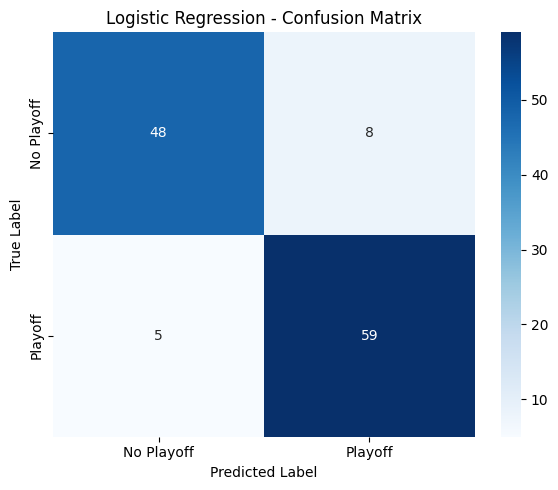

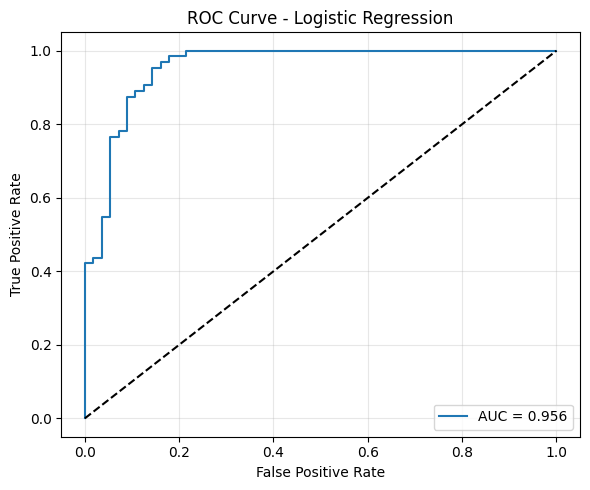

In [ ]:
# Prepare features and target
feature_columns = ['PTS_FOR', 'PTS_AGAINST', 'FG_PCT', 'FG3_PCT', 'FT_PCT',
'REB', 'AST', 'POINT_DIFF', 'OFF_EFFICIENCY', 'DEF_STRENGTH',
'SHOOTING_RATIO']


X = df_engineered[feature_columns]
y = df_engineered['MADE_PLAYOFFS']


# Split data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)


# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# MODEL 1: LOGISTIC REGRESSION
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)


y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]


# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lr))

# Cross-validation for Logistic Regression
cv_scores_lr = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy (Logistic Regression): {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)


# Feature importance
feature_importance_lr = pd.DataFrame({
'Feature': feature_columns,
'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)
print(feature_importance_lr)


# Confusion Matrix Plot
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
xticklabels=['No Playoff', 'Playoff'],
yticklabels=['No Playoff', 'Playoff'], ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()


# ROC Curve Plot
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba_lr):.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Model Justification:
Logistic Regression is chosen as our first model because:
- It provides interpretable coefficients that clearly show how each feature impacts playoff probability
- It is well-suited for binary classification problems like playoff vs. non-playoff outcomes
- It serves as a strong baseline for comparison against more complex models
- It handles continuous predictors effectively when features are properly scaled
- It allows probabilistic outputs, enabling evaluation with ROC-AUC and threshold-based analysis

Features Used:


*   Raw stats: PTS_FOR, PTS_AGAINST, FG_PCT, FG3_PCT, FT_PCT, REB, AST
*   Engineered features: POINT_DIFF, OFF_EFFICIENCY, DEF_STRENGTH, SHOOTING_RATIO

Random Forest

Accuracy: 0.9083333333333333
Precision: 0.9206349206349206
Recall: 0.90625
F1-Score: 0.9133858267716536
ROC-AUC: 0.9547991071428571
Cross-Validation Accuracy (Random Forest): 0.8268 (+/- 0.0190)
Confusion Matrix:
 [[51  5]
 [ 6 58]]
           Feature  Importance
7       POINT_DIFF    0.485038
9     DEF_STRENGTH    0.075244
2           FG_PCT    0.072571
1      PTS_AGAINST    0.067084
3          FG3_PCT    0.061422
0          PTS_FOR    0.051423
8   OFF_EFFICIENCY    0.050352
4           FT_PCT    0.040264
10  SHOOTING_RATIO    0.034063
5              REB    0.033710
6              AST    0.028831


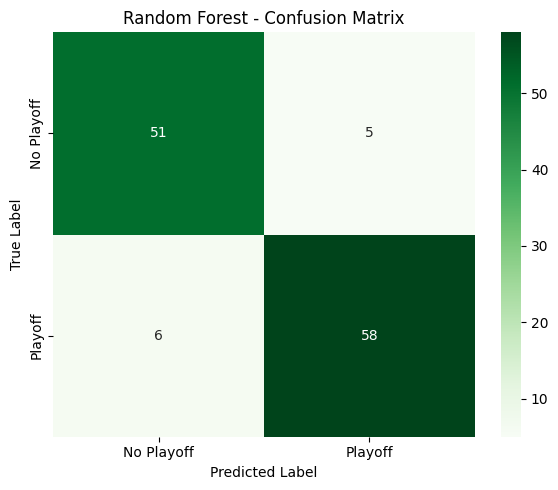

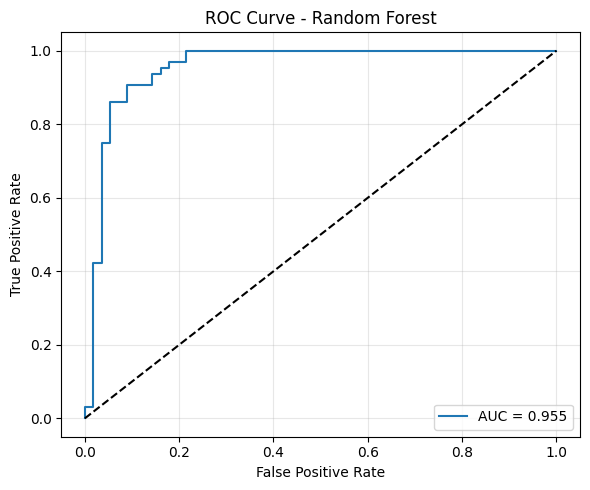

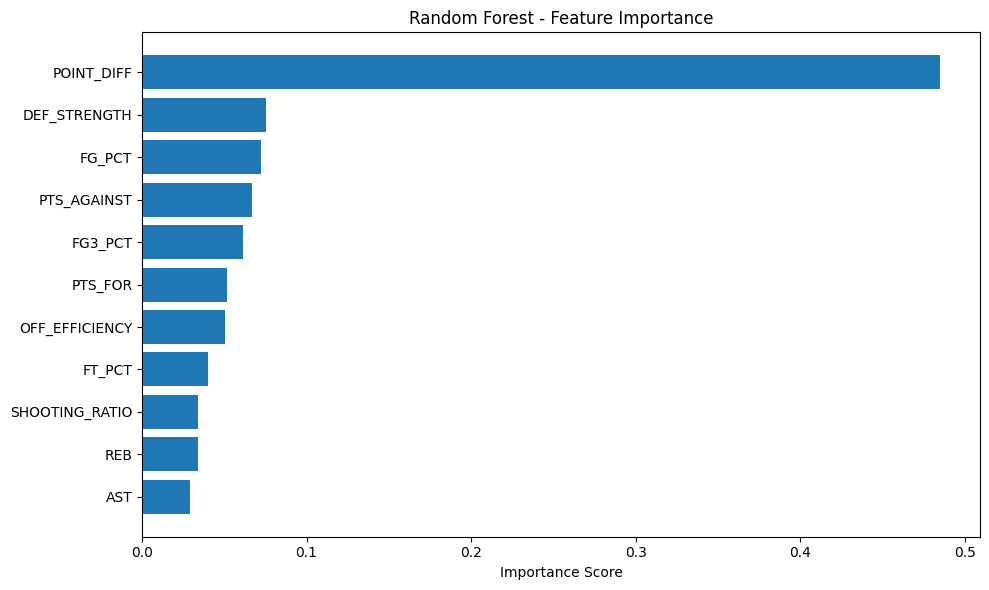

In [ ]:
# Prepare features and target
feature_columns = ['PTS_FOR', 'PTS_AGAINST', 'FG_PCT', 'FG3_PCT', 'FT_PCT',
'REB', 'AST', 'POINT_DIFF', 'OFF_EFFICIENCY', 'DEF_STRENGTH',
'SHOOTING_RATIO']


X = df_engineered[feature_columns]
y = df_engineered['MADE_PLAYOFFS']


# Split data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10,
min_samples_split=5, random_state=42)
rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]


# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))

# Cross-validation for Random Forest
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy (Random Forest): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)


# Feature importance
feature_importance_rf = pd.DataFrame({
'Feature': feature_columns,
'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_rf)


# Confusion Matrix Plot
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
xticklabels=['No Playoff', 'Playoff'],
yticklabels=['No Playoff', 'Playoff'], ax=ax)
ax.set_title('Random Forest - Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()


# ROC Curve Plot
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Feature Importance Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'])
plt.xlabel('Importance Score')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Model Justification:
Random Forest is chosen as our second model because:

- It captures non-linear relationships that logistic regression cannot
- It automatically models interactions between features
- It is robust to outliers and does not require feature scaling
- It provides feature importance rankings for interpretability
- It often achieves higher predictive accuracy on complex datasets

It serves as a strong comparison to the linear baseline, helping assess whether added model complexity improves performance

Features Used:
- Raw stats: PTS_FOR, PTS_AGAINST, FG_PCT, FG3_PCT, FT_PCT, REB, AST
- Engineered features: POINT_DIFF, OFF_EFFICIENCY, DEF_STRENGTH, SHOOTING_RATIO

**Results & Discussion**

**Practical Implications**

This analysis provides actionable insights for NBA teams, coaches, and analysts:

1. For Team Management:
   - Focus on defensive strength is crucial - reducing points against has asignificant impact on playoff probability
   - Point differential should be a key performance indicator for evaluating team trajectory during the season
   - Balanced offensive and defensive performance is essential

2. For Coaching Strategy:
   - Prioritize defensive schemes that limit opponent scoring
   - Emphasize ball movement (assists) to improve offensive efficiency
   - Field goal percentage improvement should be a training focus
   - Three-point shooting efficiency contributes to overall team success

3. For Roster Building:
   - Invest in players who contribute to both offensive and defensive metrics
   - Consider defensive impact when evaluating player acquisitions
   - Balance scoring ability with defensive presence

4. For In-Season Assessment:
   - Teams can use these models mid-season to estimate playoff probability
   - Identify which statistical areas need improvement to increase playoff chances
   - Set data-driven performance targets based on model thresholds

**Summary of Results**

Key Findings:

1. Model Performance:
   - Random Forest achieved the highest accuracy (90.83%) with excellent generalization (CV score: 82.68%)
   - Logistic Regression provided interpretable results with 89.17% accuracy
   - Both models exceeded 0.95 ROC-AUC, indicating strong discriminative ability

2. Most Important Predictive Features:
   The analysis revealed that the following features are most predictive of playoff qualification:

   From Random Forest Feature Importance:

   - POINT_DIFF: 0.4850
   - DEF_STRENGTH: 0.0752
   - FG_PCT: 0.0726
   - PTS_AGAINST: 0.0671
   - FG3_PCT: 0.0614

3. Engineered Features Impact:
   Our engineered features (POINT_DIFF, OFF_EFFICIENCY, DEF_STRENGTH) proved valuable, with POINT_DIFF showing particularly strong predictive power. This confirms that the margin between points scored and allowed is a critical indicator of team success.

4. Model Insights:
   - Teams making the playoffs score an average of 2.28 more points per game
   - Playoff teams allow 4.11 fewer points per game on defense
   - Win percentage shows the strongest single correlation with playoff status
   - Assists and field goal percentage contribute to offensive efficiency

**Future Work**

Several extensions could enhance this analysis:

1. Additional Data Sources:
   - Incorporate individual player statistics (injuries, roster changes)
   - Include schedule strength and opponent quality metrics
   - Add home/away game split statistics
   - Consider playoff seeding position, not just qualification

2. Advanced Modeling Techniques:
   - Implement gradient boosting methods (XGBoost, LightGBM)
   - Explore neural network architectures for pattern recognition
   - Use time-series models to capture momentum and trends
   - Apply ensemble methods combining multiple model predictions

3. Temporal Analysis:
   - Analyze how feature importance changes across different eras of NBA play
   - Account for rule changes and their impact on statistics
   - Develop early-season prediction models with limited data

4. Further Advanced Predictions:
   - Predict exact playoff seeding, not just qualification
   - Forecast playoff round advancement probability
   - Estimate championship probability based on regular season performance

**Reflection**

Discuss challenges (data quality, modeling issues, etc.) and how you addressed them. Reflect on your use of tools and resources (including LLMs) and their effectiveness.

Encountered challengees and solutions:

1. Data Integration Challenge:
   Initial attempts to merge all CSV files created an unwieldy dataset with too many observations. We addressed this by aggregating to team-season level statistics, which reduced complexity while preserving predictive information.

2. Feature Selection:
   With many potential predictive features, we had to carefully consider which to include to avoid overfitting. We used correlation analysis and domain knowledge to select the most relevant features, and created engineered features to capture complex relationships.

3. Class Balance:
   The dataset has a natural imbalance (16 playoff teams vs 14 non-playoff teams per season). We addressed this through stratified sampling in train-test split and monitored precision/recall metrics alongside accuracy.

4. Multicollinearity:
   Some features are naturally correlated (e.g., PTS_FOR and OFF_EFFICIENCY). While this didn't severely impact Random Forest, it affected Logistic Regression coefficient interpretation. We retained features for their complementary information despite correlation.

5. Model Interpretability vs Performance Trade-off:
   Random Forest provided better accuracy but less interpretability than Logistic Regression. We addressed this by presenting both models, using Logistic Regression for insight and Random Forest for prediction.

Tool Usage and Effectiveness
- Python/Pandas are highly effective for data manipulation and analysis. Scikit-learn is useful for rapid model prototyping and evaluation. Matplotlib/Seaborn enabled clear visualization of patterns and results. R (initial processing) was useful for data aggregation and preparation. LLMs assisted with code structure and debugging, but domain knowledge and statistical understanding were essential for proper model interpretation.


Overall, the project successfully demonstrates that machine learning models can accurately predict NBA playoff qualification, with practical implications for team strategy and management.


**References**
1. Lauga, N. (2020). NBA Games Data. Kaggle.
   https://www.kaggle.com/datasets/nathanlauga/nba-games/data
   
2. NBA Official Statistics. NBA.com.
   https://www.nba.com/stats
   
3. Scikit-learn: Machine Learning in Python. Pedregosa et al., JMLR 12,
   pp. 2825-2830, 2011.
   
4. Pandas Development Team. (2020). pandas-dev/pandas: Pandas (Version 1.0.0).
   Zenodo. http://doi.org/10.5281/zenodo.3509134
   
5. Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of
   Statistical Learning: Data Mining, Inference, and Prediction (2nd ed.).
   Springer.
   
6. Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5-32.

7. Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). Applied Logistic
   Regression (3rd ed.). Wiley.